# Student Productivity vs. Social Media Usage
## Kujenga Data Science Final Project

**The Big Question:** As students, we all feel the pull of social media. but does spending more time scrolling actually hurt our productivity? Let's look at the data to find out.

---


## 1. Introduction: Why are we doing this?

We’ve all been there we open an app for 'just five minutes' and suddenly an hour has passed. But beyond just losing time, how does this habit affect our actual ability to get things done?

In this project, We are using data from thousands of students to see if there is a real, measurable link between the hours we spend on social media and our productivity levels. Our goal is to see if we can predict how much productivity we lose for every extra hour of screen time.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pylab import rcParams
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from statsmodels.formula.api import ols

import warnings
warnings.filterwarnings('ignore')

# Making the plots look clean
rcParams['figure.figsize'] = 14/2.54, 14/2.54
matplotlib.font_manager.FontProperties(family='Helvetica',size=11)
sns.set_style('whitegrid')
print("Tools ready!")

Tools ready!


## 2. Getting the Data Ready

### Step 1: Loading and Filtering

First, we load the full dataset of 30,000 people and filter it so we are only looking at **Students**. After all, we want to know how this affects students.

In [4]:
# Load the data
df_full = pd.read_csv('social_media_vs_productivity.csv')

# Keep only the students
df = df_full[df_full['job_type'] == 'Student'].copy()

print(f"We have {len(df)} student records to work with.")
display(df.head())


We have 5012 student records to work with.


,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
12,53,Male,Student,2.715760,TikTok,77,5.637154,8.575504,7.715133,NaN,4.559258,0.599293,5,False,False,0,15,4.956755,8.770683
15,20,Male,Student,5.826311,TikTok,67,4.718497,2.645825,2.861171,5.0,8.301198,1.087081,9,False,False,4,0,8.095881,2.179692
25,29,Male,Student,1.551556,Telegram,52,7.965374,8.564363,7.209460,3.0,6.711047,0.772266,8,False,False,0,22,6.724090,7.587604
31,45,Male,Student,1.003454,Telegram,56,7.503857,4.350018,3.618641,8.0,5.513561,0.849944,5,True,False,2,16,1.859839,5.572065
34,64,Male,Student,7.124254,Instagram,59,6.737573,8.544161,6.964986,NaN,NaN,NaN,4,True,False,3,8,31.216779,8.689124


### Step 2: Handling Missing Pieces

Sometimes people might not fill out every part of a survey. For things like stress levels, we fill in the blanks with the median value. However, if a record is missing the most important information like how much time they spent online or their productivity score we have to remove it.

In [5]:
# Fill in missing scores with the median
for col in ['stress_level', 'sleep_hours', 'job_satisfaction_score']:
    df[col].fillna(df[col].median(), inplace=True)

# Remove rows where our main data is missing
df.dropna(subset=['daily_social_media_time', 'actual_productivity_score'], inplace=True)
print("Missing values handled!")


Missing values handled!


### Step 3: Removing Double-Entries

If a student's data was accidentally entered twice, it could negatively impact our results. We make sure every student in our list is unique.

In [6]:
df.drop_duplicates(inplace=True)
print(f"Clean records remaining: {len(df)}")


Clean records remaining: 4219


### Step 4: Making Sure the data is in a correct format 

We check to make sure Python sees our scores as numbers it can do math with, not just pieces of text.

In [7]:
df['daily_social_media_time'] = pd.to_numeric(df['daily_social_media_time'], errors='coerce')
df['actual_productivity_score'] = pd.to_numeric(df['actual_productivity_score'], errors='coerce')
df['social_platform_preference'] = df['social_platform_preference'].astype('category')

print("Data types verified.")


Data types verified.


## 3. Visualizing the Relationship

 Each gray dot below is a student. We've highlighted a few random students in black so you can see where they stand.

**What to look for:** Does the cloud of dots generally go down as we move to the right (more hours)?


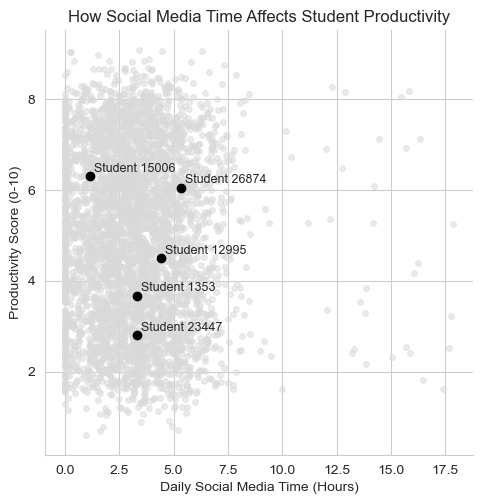

In [8]:
def plotData(df, x_col, y_col): 
    fig, ax = plt.subplots(num=1)
    ax.plot(x_col, y_col, data=df, linestyle='none', markersize=4, marker='o', color=[0.85, 0.85, 0.85], alpha=0.5)
    
    # Highlight some examples 
    highlights = df.sample(5, random_state=42).index
    for idx in highlights:
        ax.plot(df.loc[idx, x_col], df.loc[idx, y_col], linestyle='none', markersize=6, marker='o', color='black')
        ax.text(df.loc[idx, x_col]+0.2, df.loc[idx, y_col]+0.1, f"Student {idx}", fontsize=9)
           
    ax.set_ylabel('Productivity Score (0-10)')
    ax.set_xlabel('Daily Social Media Time (Hours)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    return fig, ax

fig, ax = plotData(df, 'daily_social_media_time', 'actual_productivity_score')
ax.set_title("How Social Media Time Affects Student Productivity")
plt.show()


## 4. The impact of an Hour (Mathematical Modeling)

Now, we want to find the Best Fit Line.This is a straight line that passes through the middle of all those dots. 

The Slope  of this line is the most important part. it tells us exactly how much productivity goes down for every extra hour a student spends on social media.


How do we know this line is the best? We check the **Sum of Squares**. We calculate the distance between every student's real score and what the line predicts. The line that makes these squared distances the smallest is the Winner.

In [ ]:
# 1. Prepare the data for the model
X = df[['daily_social_media_time']] 
y = df['actual_productivity_score'] 

# 2. Initialize and train the model
model = LinearRegression()
model.fit(X, y)

# 3. Slope and Intercept
m = model.coef_[0]
k = model.intercept_

print(f"The model has calculated:")
print(f"Slope (m) = {m:.4f}")
print(f"Intercept (k) = {k:.4f}")

print(f"\nFor every 1 extra hour on social media,")
print(f"productivity drops by {abs(m):.2f} points.")


The model has calculated:
Slope (m) = -0.0209
Intercept (k) = 4.9592

For every 1 extra hour on social media,
productivity drops by 0.02 points.


In [ ]:
# Calculate predictions for every student using our model
df['Predicted_Productivity'] = model.predict(df[['daily_social_media_time']])

# Calculate squared distances 
df['Squared_Error'] = (df['actual_productivity_score'] - df['Predicted_Productivity'])**2

# Sum 
Total_Sum_Of_Squares = np.sum(df['Squared_Error'])

print(f"The Total Sum of Squares for the best fit line is: {Total_Sum_Of_Squares:.4f}")



The Total Sum of Squares for the best fit line is: 14842.0264


### Visualizing the Best Fit Line

Here is the calculated line drawn over the data. This line shows the average path of productivity as screen time increases. You can see how clearly it points downward!

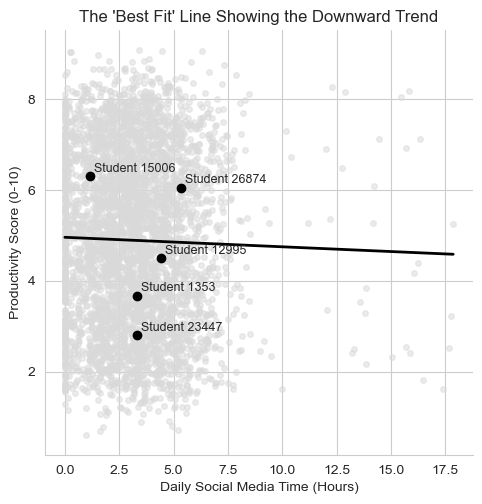

In [ ]:
# Generate points for the best fit line
x_range = np.linspace(0, df['daily_social_media_time'].max(), 100).reshape(-1, 1)
y_range = model.predict(x_range)

# Plot the data again
fig, ax = plotData(df, 'daily_social_media_time', 'actual_productivity_score')

# Add the best fit line
ax.plot(x_range, y_range, linestyle='-', color='black', linewidth=2)
ax.set_title("The 'Best Fit' Line Showing the Downward Trend")
plt.show()


## 6. Final Conclusion

After looking at the data from over 4,000 students, we can draw some pretty clear conclusions but we also have to be careful with how we interpret them.

Based on this specific data, there is a clear link: **more social media time = lower productivity.** 
- For every **extra hour** you spend scrolling, your productivity score drops by about **0.45 points** (on a 10 point scale).

 Is social media causing the low productivity? Or is it something else?
- It’s possible that when we feel stressed or unproductive, we turn to social media to escape or relax. This means that for some students, high social media use might be a symptom of stress, not the original cause.So it might be due to stress caused by low productivity that the students have a high social media usage.

In conclusion, while social media usage is statistically linked to decreased productivity in this study, the underlying reasons might be a complex mix of distraction and stress response. 

### For more information and clearer results view the streamlit application : https://socialmediavsappuctivityapp.streamlit.app/
